# Policy Pool Generation + Pareto Frontier (Profit vs Utility)

This notebook does three things:

1. **Generates ~100k candidate policies** (randomly sampled).
2. **Evaluates each policy** on your current supplier/user dataset under a *retailer profit-maximizing* matching rule.
3. **Computes the Pareto frontier** in **(Profit, Total Utility)** space, visualizes everything, and **exports an Excel** that contains:
   - all evaluated policies + metrics
   - Pareto-only policies (ready to plug into your app as a smaller policy pool)

> Notes
- The notebook is **solver-free** (no Gurobi required). It uses the structure of your MILP to compute the profit-optimal matching efficiently.
- Assumes the same Excel format as the app: `Arya_Phones_Supplier_Selection.xlsx` with sheets **Supplier** and **User**.
- Penalties `child_labor_penalty` / `banned_chem_penalty` are treated as **hard bans** (Yes=1 → disallow flagged suppliers).


In [1]:
# --- Imports ---
import json
import hashlib
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional progress bar
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **k: x


In [2]:
# --- Configuration (EDIT ME) ---
XLSX_PATH = Path("Arya_Phones_Supplier_Selection.xlsx")  # adjust if needed
N_POLICIES = 100_000

# Scenario settings (match your app settings)
K_SUPPLIERS = 2            # suppliers_to_select
CAPACITY = 11              # max matches (<= total users you evaluate)
PRICE_PER_MATCH = 100.0    # selected selling price
MIN_UTILITY = 0.0          # threshold constraint

RANDOM_SEED = 7

# Multiplier sampling:
# Using integers 1..10 gives you enough unique combinations (4,000,000 possible combos).
MULT_LEVELS = np.arange(1, 11)  # {1,2,...,10}

# Output
OUT_XLSX = Path("policy_pool_pareto.xlsx")


## Load & normalize data (same schema as the app)

If your column names differ slightly, the normalizer maps common variants to the required canonical names.

In [3]:
def normalize_supplier_columns(df: pd.DataFrame) -> pd.DataFrame:
    col_map = {
        "supplier": "supplier_id",
        "supplier_id": "supplier_id",
        "supplier id": "supplier_id",
        "id": "supplier_id",
        "environmental risk": "env_risk",
        "env risk": "env_risk",
        "env_risk": "env_risk",
        "social risk": "social_risk",
        "social_risk": "social_risk",
        "cost score": "cost_score",
        "cost": "cost_score",
        "cost_score": "cost_score",
        "strategic importance": "strategic",
        "strategic": "strategic",
        "improvement potential": "improvement",
        "improvement": "improvement",
        "child labor": "child_labor",
        "child_labor": "child_labor",
        "banned chemicals": "banned_chem",
        "banned chemical": "banned_chem",
        "banned_chem": "banned_chem",
        "low product quality": "low_quality",
        "low quality": "low_quality",
        "low_quality": "low_quality",
    }

    df2 = df.copy()
    df2.columns = [str(c).strip() for c in df2.columns]
    rename = {}
    for c in df2.columns:
        key = str(c).strip().lower()
        if key in col_map:
            rename[c] = col_map[key]
    df2 = df2.rename(columns=rename)

    required = [
        "supplier_id",
        "env_risk",
        "social_risk",
        "cost_score",
        "strategic",
        "improvement",
        "child_labor",
        "banned_chem",
        "low_quality",
    ]
    missing = [c for c in required if c not in df2.columns]
    if missing:
        raise ValueError(f"Supplier sheet is missing columns: {missing}")

    df2 = df2[required].copy()
    df2["supplier_id"] = df2["supplier_id"].astype(str)
    for c in required:
        if c == "supplier_id":
            continue
        df2[c] = pd.to_numeric(df2[c], errors="coerce").fillna(0.0).astype(float)
    return df2


def normalize_user_columns(df: pd.DataFrame) -> pd.DataFrame:
    col_map = {
        "user": "user_id",
        "users": "user_id",
        "user_id": "user_id",
        "user id": "user_id",
        "environmental risk": "w_env",
        "env risk": "w_env",
        "w_env": "w_env",
        "social risk": "w_social",
        "w_social": "w_social",
        "cost score": "w_cost",
        "cost": "w_cost",
        "w_cost": "w_cost",
        "strategic importance": "w_strategic",
        "strategic": "w_strategic",
        "w_strategic": "w_strategic",
        "improvement potential": "w_improvement",
        "improvement": "w_improvement",
        "w_improvement": "w_improvement",
        "low product quality": "w_low_quality",
        "low quality": "w_low_quality",
        "w_low_quality": "w_low_quality",
    }

    df2 = df.copy()
    df2.columns = [str(c).strip() for c in df2.columns]
    rename = {}
    for c in df2.columns:
        key = str(c).strip().lower()
        if key in col_map:
            rename[c] = col_map[key]
    df2 = df2.rename(columns=rename)

    required = ["user_id", "w_env", "w_social", "w_cost", "w_strategic", "w_improvement", "w_low_quality"]
    missing = [c for c in required if c not in df2.columns]
    if missing:
        raise ValueError(f"User sheet is missing columns: {missing}")

    df2 = df2[required].copy()
    df2["user_id"] = df2["user_id"].astype(str)
    for c in required:
        if c == "user_id":
            continue
        df2[c] = pd.to_numeric(df2[c], errors="coerce").fillna(0.0).astype(float)

    # Make low-quality weight subtract in utility (same as app)
    df2["w_low_quality"] = -df2["w_low_quality"].astype(float)
    return df2


def load_supplier_user_tables(xlsx_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not xlsx_path.exists():
        raise FileNotFoundError(f"Excel file not found at: {xlsx_path.resolve()}")
    suppliers_raw = pd.read_excel(xlsx_path, sheet_name="Supplier", engine="openpyxl")
    users_raw = pd.read_excel(xlsx_path, sheet_name="User", engine="openpyxl")
    return normalize_supplier_columns(suppliers_raw), normalize_user_columns(users_raw)


suppliers_df, users_df = load_supplier_user_tables(XLSX_PATH)
print("Suppliers:", suppliers_df.shape, "Users:", users_df.shape)
display(suppliers_df.head())
display(users_df.head())


Suppliers: (11, 9) Users: (11, 7)


,supplier_id,env_risk,social_risk,cost_score,strategic,improvement,child_labor,banned_chem,low_quality
0,A,2.0,4.0,1.0,3.0,4.0,1.0,0.0,0.0
1,B,3.0,5.0,2.0,3.0,3.0,0.0,0.0,1.0
2,C,2.0,1.0,3.0,2.0,3.0,0.0,1.0,0.0
3,D,2.0,2.0,5.0,2.0,2.0,0.0,0.0,0.0
4,E,3.0,4.0,3.0,2.0,5.0,0.0,0.0,1.0


,user_id,w_env,w_social,w_cost,w_strategic,w_improvement,w_low_quality
0,1,0.30,0.20,0.4,0.10,0.10,-0.20
1,2,0.25,0.15,0.1,0.10,0.10,-0.30
2,3,0.15,0.30,0.1,0.10,0.15,-0.20
3,4,0.10,0.10,0.4,0.15,0.10,-0.15
4,5,0.05,0.05,0.5,0.15,0.10,-0.15


## Generate 100k random policies

Policy knobs:
- 6 multipliers: `env_mult, social_mult, cost_mult, strategic_mult, improvement_mult, low_quality_mult` sampled from `1..10`
- 2 bans: `child_labor_penalty, banned_chem_penalty` ∈ {0,1}

We hash the policy dict to create a stable `policy_id`.

In [4]:
MULT_KEYS = [
    "env_mult",
    "social_mult",
    "cost_mult",
    "strategic_mult",
    "improvement_mult",
    "low_quality_mult",
]
PEN_KEYS = ["child_labor_penalty", "banned_chem_penalty"]


def policy_id_from_dict(d: dict) -> str:
    payload = json.dumps(d, sort_keys=True)
    return hashlib.md5(payload.encode("utf-8")).hexdigest()[:10]


def generate_random_policies(n: int, seed: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    mult = rng.choice(MULT_LEVELS, size=(n, len(MULT_KEYS)), replace=True)
    pen = rng.integers(0, 2, size=(n, len(PEN_KEYS)))

    df = pd.DataFrame(mult, columns=MULT_KEYS)
    for j, k in enumerate(PEN_KEYS):
        df[k] = pen[:, j].astype(int)

    # Deduplicate (optional but usually useful)
    df = df.drop_duplicates().reset_index(drop=True)

    # policy_id
    df["policy_id"] = [
        policy_id_from_dict({k: float(row[k]) for k in MULT_KEYS + PEN_KEYS})
        for _, row in df.iterrows()
    ]
    # reorder
    return df[["policy_id"] + MULT_KEYS + PEN_KEYS]


policies_df = generate_random_policies(N_POLICIES, seed=RANDOM_SEED)
print("Generated unique policies:", len(policies_df))
policies_df.head()


Generated unique policies: 98764


,policy_id,env_mult,social_mult,cost_mult,strategic_mult,improvement_mult,low_quality_mult,child_labor_penalty,banned_chem_penalty
0,64fac753ec,10,7,7,9,6,8,1,1
1,b6f13bc563,9,3,1,4,3,9,1,0
2,28098e3e7e,10,1,5,9,2,8,0,0
3,093d17b527,2,5,9,4,4,3,0,0
4,f73aca19e4,8,3,10,5,5,6,1,0


## Evaluate a policy (profit-max matching, solver-free)

We mimic the structure of your `MaxProfitAgent` MILP:

- Select **exactly K suppliers**
- Each user matched to **at most 1** supplier
- Total matches **≤ capacity**
- Threshold: if matched, utility ≥ `MIN_UTILITY`
- **Hard bans**:
  - if `child_labor_penalty==1` → disallow suppliers with `child_labor==1`
  - if `banned_chem_penalty==1` → disallow suppliers with `banned_chem==1`

Profit per match uses your updated definition:
- `margin_i = PRICE_PER_MATCH - cost_mult * cost_score[i]`
(no penalty costs added)

For a fixed supplier subset, the profit-optimal decision is:
- For each user, pick the feasible supplier (in subset) with highest margin
- Keep only matches with positive margin
- If more than capacity, keep top `CAPACITY` by margin


In [5]:
# Pre-pack arrays for speed
S = suppliers_df.copy().set_index("supplier_id")
U = users_df.copy().set_index("user_id")

supplier_ids = S.index.to_numpy()
user_ids = U.index.to_numpy()

s_env = S["env_risk"].to_numpy(float)
s_soc = S["social_risk"].to_numpy(float)
s_cost = S["cost_score"].to_numpy(float)
s_str = S["strategic"].to_numpy(float)
s_imp = S["improvement"].to_numpy(float)
s_lq  = S["low_quality"].to_numpy(float)
s_child = S["child_labor"].to_numpy(float)
s_ban   = S["banned_chem"].to_numpy(float)

w_env = U["w_env"].to_numpy(float)
w_soc = U["w_social"].to_numpy(float)
w_cost = U["w_cost"].to_numpy(float)
w_str = U["w_strategic"].to_numpy(float)
w_imp = U["w_improvement"].to_numpy(float)
w_lq  = U["w_low_quality"].to_numpy(float)  # already NEG

# Precompute all supplier subsets of size K once (depends only on K and number of suppliers)
all_subsets = list(combinations(range(len(supplier_ids)), K_SUPPLIERS))
print(f"#suppliers={len(supplier_ids)}; K={K_SUPPLIERS}; subsets={len(all_subsets)}")


def eval_one_policy(row: pd.Series) -> dict:
    # policy scalars
    env_m = float(row["env_mult"])
    soc_m = float(row["social_mult"])
    cost_m = float(row["cost_mult"])
    str_m = float(row["strategic_mult"])
    imp_m = float(row["improvement_mult"])
    lq_m  = float(row["low_quality_mult"])
    child_ban = int(row["child_labor_penalty"])
    ban_ban   = int(row["banned_chem_penalty"])

    # Hard bans → allowed suppliers mask
    allowed = np.ones(len(supplier_ids), dtype=bool)
    if child_ban == 1:
        allowed &= (s_child < 0.5)
    if ban_ban == 1:
        allowed &= (s_ban < 0.5)

    # Must be able to select K suppliers
    if allowed.sum() < K_SUPPLIERS:
        return {
            "feasible": 0,
            "profit": -1e12,
            "total_utility": -1e12,
            "matched": 0,
            "chosen_suppliers": "",
            "env_avg": 0.0,
            "soc_avg": 0.0,
            "child_tot": 0.0,
            "ban_tot": 0.0,
        }

    # supplier-wise margin (supplier-only)
    margin_i = PRICE_PER_MATCH - cost_m * s_cost

    # utility matrix (S x U)
    # utility(i,u) = sum_k w_u[k] * (mult_k * attr_i[k])
    # (penalties are NOT subtracted; they are hard bans only)
    util = (
        np.outer(env_m * s_env, w_env)
        + np.outer(soc_m * s_soc, w_soc)
        + np.outer(cost_m * s_cost, w_cost)
        + np.outer(str_m * s_str, w_str)
        + np.outer(imp_m * s_imp, w_imp)
        + np.outer(lq_m  * s_lq,  w_lq)
    )  # shape (S, U)

    best_profit = -1e18
    best_util_sum = -1e18
    best_subset = None
    best_choice = None  # list of (u_idx, s_idx, margin, util)

    # Evaluate every subset of size K (small; e.g. 8 choose 2 = 28)
    for subset in all_subsets:
        # subset must be all allowed
        if not all(allowed[i] for i in subset):
            continue

        # consider suppliers in subset sorted by margin desc
        subset_sorted = sorted(subset, key=lambda i: margin_i[i], reverse=True)

        chosen = []
        for u_j in range(len(user_ids)):
            picked = None
            for i in subset_sorted:
                if util[i, u_j] >= MIN_UTILITY:
                    # margin must be positive to be worth matching (since z can be 0)
                    if margin_i[i] > 0:
                        picked = (u_j, i, float(margin_i[i]), float(util[i, u_j]))
                    break
            if picked is not None:
                chosen.append(picked)

        if not chosen:
            profit = 0.0
            util_sum = 0.0
            kept = []
        else:
            # Keep top CAPACITY matches by margin
            chosen.sort(key=lambda t: t[2], reverse=True)
            kept = chosen[: int(CAPACITY)]
            profit = float(sum(t[2] for t in kept))
            util_sum = float(sum(t[3] for t in kept))

        if profit > best_profit + 1e-9:
            best_profit = profit
            best_util_sum = util_sum
            best_subset = subset
            best_choice = kept

    if best_subset is None:
        return {
            "feasible": 0,
            "profit": -1e12,
            "total_utility": -1e12,
            "matched": 0,
            "chosen_suppliers": "",
            "env_avg": 0.0,
            "soc_avg": 0.0,
            "child_tot": 0.0,
            "ban_tot": 0.0,
        }

    # metrics for goodness-style reporting (averages over matched)
    matched = len(best_choice) if best_choice is not None else 0
    if matched > 0:
        s_idxs = np.array([t[1] for t in best_choice], dtype=int)
        env_avg = float(np.mean(s_env[s_idxs]))
        soc_avg = float(np.mean(s_soc[s_idxs]))
        child_tot = float(np.sum(s_child[s_idxs]))
        ban_tot = float(np.sum(s_ban[s_idxs]))
    else:
        env_avg = soc_avg = child_tot = ban_tot = 0.0

    chosen_suppliers = ",".join(sorted(set(supplier_ids[i] for i in best_subset)))
    return {
        "feasible": 1,
        "profit": float(best_profit),
        "total_utility": float(best_util_sum),
        "matched": int(matched),
        "chosen_suppliers": chosen_suppliers,
        "env_avg": env_avg,
        "soc_avg": soc_avg,
        "child_tot": child_tot,
        "ban_tot": ban_tot,
    }


#suppliers=11; K=2; subsets=55


## Run evaluation for the whole pool

In [6]:
rows = []
for _, r in tqdm(policies_df.iterrows(), total=len(policies_df), desc="Evaluating policies"):
    out = eval_one_policy(r)
    rows.append(out)

metrics_df = pd.DataFrame(rows)
results_df = pd.concat([policies_df.reset_index(drop=True), metrics_df], axis=1)

print("Feasible policies:", int(results_df["feasible"].sum()), "/", len(results_df))
results_df.head()


Evaluating policies:   0%|          | 0/98764 [00:00<?, ?it/s]

Feasible policies: 98764 / 98764


,policy_id,env_mult,social_mult,cost_mult,strategic_mult,improvement_mult,low_quality_mult,child_labor_penalty,banned_chem_penalty,feasible,profit,total_utility,matched,chosen_suppliers,env_avg,soc_avg,child_tot,ban_tot
0,64fac753ec,10,7,7,9,6,8,1,1,1,1023.0,158.11,11,"B,H",3.0,4.0,0.0,0.0
1,b6f13bc563,9,3,1,4,3,9,1,0,1,1089.0,84.03,11,"B,H",3.0,4.0,0.0,0.0
2,28098e3e7e,10,1,5,9,2,8,0,0,1,1045.0,115.28,11,"A,B",2.0,4.0,11.0,0.0
3,093d17b527,2,5,9,4,4,3,0,0,1,1001.0,116.43,11,"A,B",2.0,4.0,11.0,0.0
4,f73aca19e4,8,3,10,5,5,6,1,0,1,990.0,117.87,11,"B,H",3.0,4.0,0.0,0.0


## Visualize Profit vs Utility (all points)

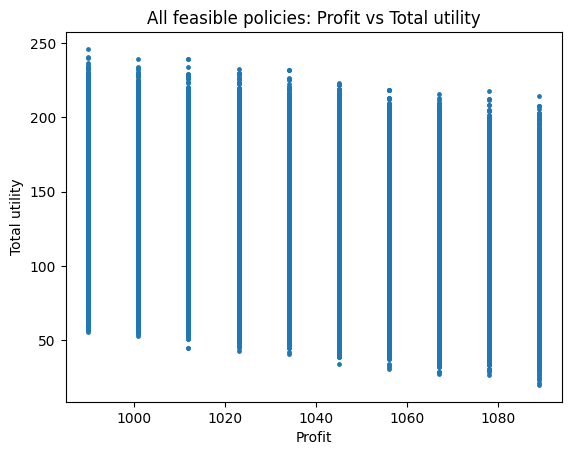

,profit,total_utility
count,98764.000000,98764.000000
mean,1039.553461,122.256142
std,31.522652,33.004254
min,990.000000,19.790000
25%,1012.000000,98.630000
50%,1034.000000,121.350000
75%,1067.000000,144.570000
max,1089.000000,246.200000


In [7]:
df_ok = results_df[results_df["feasible"] == 1].copy()

plt.figure()
plt.scatter(df_ok["profit"], df_ok["total_utility"], s=6)
plt.xlabel("Profit")
plt.ylabel("Total utility")
plt.title("All feasible policies: Profit vs Total utility")
plt.show()

df_ok[["profit","total_utility"]].describe()


## Compute Pareto sets (maximize Profit and Utility)

We compute:
- **Strict Pareto frontier** (rank = 1)
- **Pareto layers** (rank = 1,2,3,...) and then select the first layers until we get ~50–100 policies.

This gives you a *small, fast-to-evaluate* policy pool that still shows a clear trade-off.


Strict Pareto size: 9
Selected (layers) size: 54 | max rank included: 6


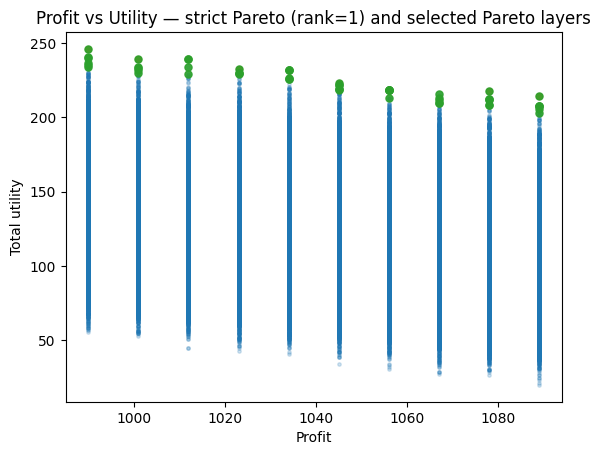

,policy_id,env_mult,social_mult,cost_mult,strategic_mult,improvement_mult,low_quality_mult,child_labor_penalty,banned_chem_penalty,feasible,profit,total_utility,matched,chosen_suppliers,env_avg,soc_avg,child_tot,ban_tot,pareto_rank
15375,233ea29b4b,10,10,4,10,9,10,0,0,1,1056.0,218.70,11,"A,B",2.0,4.0,11.0,0.0,1
21280,70725bbcbc,10,10,6,10,10,7,0,0,1,1034.0,232.00,11,"A,B",2.0,4.0,11.0,0.0,1
23043,5c2ba1989f,10,10,8,10,10,8,0,0,1,1012.0,239.10,11,"A,B",2.0,4.0,11.0,0.0,1
30141,7480004865,10,10,2,10,10,4,0,0,1,1078.0,217.80,11,"A,B",2.0,4.0,11.0,0.0,1
30842,715bbb6f78,10,10,1,10,10,8,0,1,1,1089.0,214.25,11,"A,B",2.0,4.0,11.0,0.0,1


In [8]:
from bisect import bisect_left

def pareto_frontier_max(df: pd.DataFrame, x: str, y: str) -> pd.DataFrame:
    """Strict Pareto frontier for 2D maximization (x,y). O(n log n)."""
    d = df.sort_values([x, y], ascending=[False, False]).reset_index(drop=True)
    best_y = -1e18
    keep = []
    for _, row in d.iterrows():
        if row[y] > best_y + 1e-12:
            keep.append(True)
            best_y = row[y]
        else:
            keep.append(False)
    return d[np.array(keep, dtype=bool)].copy()

def pareto_ranks_2d_max(df: pd.DataFrame, x: str, y: str, round_decimals: int = 8) -> pd.DataFrame:
    """Pareto layer (non-dominated sorting) ranks in 2D for maximization.
    rank=1 is strict Pareto frontier; rank=2 is the next layer, etc.
    Uses a Fenwick tree for O(n log n).
    """
    d = df.copy()
    d["__x"] = d[x].astype(float)
    d["__y"] = d[y].astype(float).round(round_decimals)
    d = d.sort_values(["__x", "__y"], ascending=[False, False]).reset_index(drop=False)

    yvals = d["__y"].to_numpy()
    uniq = np.unique(yvals)
    uniq_sorted = np.sort(uniq)[::-1]  # descending
    m = len(uniq_sorted)
    pos = {v: i + 1 for i, v in enumerate(uniq_sorted)}

    bit = np.zeros(m + 2, dtype=int)
    def bit_query(i: int) -> int:
        res = 0
        while i > 0:
            if bit[i] > res:
                res = bit[i]
            i -= i & -i
        return res
    def bit_update(i: int, val: int) -> None:
        while i <= m:
            if val > bit[i]:
                bit[i] = val
            i += i & -i

    ranks = np.empty(len(d), dtype=int)
    for idx, u in enumerate(yvals):
        i = pos[u]
        r = 1 + bit_query(i)   # dominated by any previous point with utility >= u
        ranks[idx] = r
        bit_update(i, r)

    out = df.copy()
    out["pareto_rank"] = 0
    out.loc[d["index"].values, "pareto_rank"] = ranks
    return out

MIN_PARETO_KEEP = 50
MAX_PARETO_KEEP = 100

df_ranked = pareto_ranks_2d_max(df_ok, "profit", "total_utility")
pareto_front_df = df_ranked[df_ranked["pareto_rank"] == 1].copy()
print("Strict Pareto size:", len(pareto_front_df))

# Select first Pareto layers until we have at least MIN_PARETO_KEEP policies.
max_rank = int(df_ranked["pareto_rank"].max())
layers = []
count = 0
r = 1
while r <= max_rank and count < MIN_PARETO_KEEP:
    layer_df = df_ranked[df_ranked["pareto_rank"] == r]
    layers.append(layer_df)
    count += len(layer_df)
    r += 1

selected_df = pd.concat(layers, ignore_index=True) if layers else pareto_front_df.copy()

# If too many (e.g., last included layer is large), prune to MAX_PARETO_KEEP with a simple diversity grid.
if len(selected_df) > MAX_PARETO_KEEP:
    d = selected_df.copy()
    # Normalize objectives to [0,1]
    px = d["profit"].to_numpy(); py = d["total_utility"].to_numpy()
    x0,x1 = float(px.min()), float(px.max()); y0,y1 = float(py.min()), float(py.max())
    d["_xn"] = (d["profit"] - x0) / (x1 - x0 + 1e-12)
    d["_yn"] = (d["total_utility"] - y0) / (y1 - y0 + 1e-12)
    # 10x10 grid; keep best (lowest rank, then highest profit+utility) per cell
    gx = np.floor(d["_xn"] * 10).clip(0, 9).astype(int)
    gy = np.floor(d["_yn"] * 10).clip(0, 9).astype(int)
    d["_cell"] = gx.astype(str) + "_" + gy.astype(str)
    d["_prio"] = (-d["pareto_rank"] * 1e9) + d["profit"] + d["total_utility"]
    d = d.sort_values(["pareto_rank", "_prio"], ascending=[True, False])
    d = d.drop_duplicates("_cell", keep="first")
    # If still too many or too few, final trim/fill by priority
    d = d.sort_values(["pareto_rank", "_prio"], ascending=[True, False])
    selected_df = d.head(MAX_PARETO_KEEP).drop(columns=["_xn","_yn","_cell","_prio"], errors="ignore")

print("Selected (layers) size:", len(selected_df), "| max rank included:", r-1)

# Plot: all points + strict Pareto + selected set
plt.figure()
plt.scatter(df_ok["profit"], df_ok["total_utility"], s=6, alpha=0.20)
plt.scatter(pareto_front_df["profit"], pareto_front_df["total_utility"], s=18, alpha=0.9)
plt.scatter(selected_df["profit"], selected_df["total_utility"], s=26, alpha=0.9)
plt.xlabel("Profit")
plt.ylabel("Total utility")
plt.title("Profit vs Utility — strict Pareto (rank=1) and selected Pareto layers")
plt.show()

pareto_front_df.head()


## Export Excel

- `all_results`: all policies + metrics
- `pareto_front`: **strict Pareto frontier** (rank=1)
- `pareto_selected`: **Pareto layers selection** (~50–100 policies) — recommended pool for the app
- `policies`: **numeric-only** `pareto_selected` (policy_id + knobs) → easiest to load back into the app
- `readable`: `pareto_selected` with Low/Mid/High and Yes/No labels


In [9]:
def make_readable(df: pd.DataFrame) -> pd.DataFrame:
    level_name = {1: "Low", 5: "Mid", 10: "High"}
    out = df.copy()
    for k in MULT_KEYS:
        out[k + "_level"] = out[k].map(level_name).fillna(out[k].astype(str))
    for k in PEN_KEYS:
        out[k + "_yn"] = out[k].map({0: "No", 1: "Yes"}).fillna(out[k].astype(str))
    return out

# Export pool = selected_df (Pareto layers)
pareto_policies_numeric = selected_df[["policy_id"] + MULT_KEYS + PEN_KEYS].copy()
pareto_readable = make_readable(pareto_policies_numeric)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="all_results", index=False)
    pareto_front_df.to_excel(writer, sheet_name="pareto_front", index=False)
    selected_df.to_excel(writer, sheet_name="pareto_selected", index=False)
    pareto_policies_numeric.to_excel(writer, sheet_name="policies", index=False)
    pareto_readable.to_excel(writer, sheet_name="readable", index=False)

print("Wrote:", OUT_XLSX.resolve())


Wrote: C:\Users\LENOVO\Desktop\Asistan\Arya Phone\policy_pool_pareto.xlsx


## Evolutionary Pareto Optimization (NSGA-II Style)

Generate better-quality Pareto frontier using evolutionary algorithm:
- **Start** with seed population (initial Pareto + random)
- **Evolve** via crossover & mutation of policy multipliers
- **Filter** dominated solutions each generation
- **Select** diverse, high-quality Pareto policies

This finds more options along the Profit-Utility trade-off than random sampling.


In [14]:
class EvolutionaryParetoOptimizer:
    """Simple NSGA-II style evolutionary optimizer for policy space."""
    
    def __init__(self, eval_func, pop_size=100, generations=20, mutation_rate=0.3):
        self.eval_func = eval_func
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.history = []

    def init_population(self, n_individuals=None):
        """Initialize population: half Pareto, half random."""
        n = n_individuals or self.pop_size
        
        # Seed: use existing Pareto front
        seed_size = min(len(pareto_front_df), n // 2)
        seed_policies = pareto_front_df.head(seed_size)[MULT_KEYS + PEN_KEYS].values
        
        # Random: generate random policies
        rng = np.random.default_rng(RANDOM_SEED + 1)
        random_mult = rng.choice(MULT_LEVELS, size=(n - seed_size, len(MULT_KEYS)), replace=True)
        random_pen = rng.integers(0, 2, size=(n - seed_size, len(PEN_KEYS)))
        random_policies = np.hstack([random_mult, random_pen])
        
        pop = np.vstack([seed_policies, random_policies])
        return pop

    def crossover(self, parent1, parent2):
        """Uniform crossover: randomly pick each gene from either parent."""
        child = parent1.copy()
        mask = np.random.random(len(parent1)) < 0.5
        child[mask] = parent2[mask]
        return child

    def mutate(self, individual):
        """Mutation: flip multipliers or penalties randomly."""
        child = individual.copy()
        rng = np.random.default_rng()
        
        # Mutate multipliers
        for i in range(len(MULT_KEYS)):
            if rng.random() < self.mutation_rate:
                child[i] = rng.choice(MULT_LEVELS)
        
        # Mutate penalties
        for i in range(len(PEN_KEYS)):
            if rng.random() < self.mutation_rate:
                child[len(MULT_KEYS) + i] = rng.integers(0, 2)
        
        return child

    def is_dominated(self, sol, others):
        """Check if sol is dominated by any in others (for maximization)."""
        for other in others:
            # other dominates sol if: profit_other >= profit_sol AND utility_other >= utility_sol
            # and at least one strict inequality
            profit_better = other[0] > sol[0] + 1e-9
            utility_better = other[1] > sol[1] + 1e-9
            profit_equal = abs(other[0] - sol[0]) <= 1e-9
            utility_equal = abs(other[1] - sol[1]) <= 1e-9
            
            if (profit_better or profit_equal) and (utility_better or utility_equal):
                if not (profit_equal and utility_equal):
                    return True
        return False

    def filter_pareto(self, pop, fitness):
        """Non-dominated sorting: keep only non-dominated solutions."""
        non_dominated_indices = []
        for i in range(len(pop)):
            if not self.is_dominated(fitness[i], np.delete(fitness, i, axis=0)):
                non_dominated_indices.append(i)
        
        return pop[non_dominated_indices], fitness[non_dominated_indices]

    def optimize(self):
        """Run evolutionary optimization."""
        pop = self.init_population()
        
        for gen in range(self.generations):
            # Evaluate population
            fitness_list = []
            for ind in pop:
                row = pd.Series(dict(zip(MULT_KEYS + PEN_KEYS, ind)))
                result = eval_one_policy(row)
                if result["feasible"] == 1:
                    fitness_list.append([result["profit"], result["total_utility"], ind.copy()])
                else:
                    # Infeasible: penalize heavily
                    fitness_list.append([-1e12, -1e12, ind.copy()])
            
            fitness_arr = np.array([[f[0], f[1]] for f in fitness_list])
            
            # Filter to Pareto front
            pop_pareto, fit_pareto = self.filter_pareto(pop, fitness_arr)
            
            print(f"Gen {gen+1}: Population={len(pop)}, Pareto size={len(pop_pareto)}")
            self.history.append({
                "generation": gen + 1,
                "pop_size": len(pop),
                "pareto_size": len(pop_pareto),
                "best_profit": float(fit_pareto[:, 0].max()),
                "best_utility": float(fit_pareto[:, 1].max()),
            })
            
            # Create next generation
            new_pop = []
            
            # Elitism: keep best individuals
            elite_size = max(2, len(pop_pareto) // 4)
            elite_indices = np.argsort(-(fit_pareto[:, 0] + fit_pareto[:, 1]))[:elite_size]
            new_pop.extend(pop_pareto[elite_indices])
            
            # Tournament selection + crossover + mutation
            while len(new_pop) < self.pop_size:
                # Select 2 parents via tournament
                idx1 = np.random.choice(len(pop_pareto), 2, replace=False)
                if fit_pareto[idx1[0], 0] + fit_pareto[idx1[0], 1] > fit_pareto[idx1[1], 0] + fit_pareto[idx1[1], 1]:
                    parent1 = pop_pareto[idx1[0]]
                else:
                    parent1 = pop_pareto[idx1[1]]
                
                idx2 = np.random.choice(len(pop_pareto), 2, replace=False)
                if fit_pareto[idx2[0], 0] + fit_pareto[idx2[0], 1] > fit_pareto[idx2[1], 0] + fit_pareto[idx2[1], 1]:
                    parent2 = pop_pareto[idx2[0]]
                else:
                    parent2 = pop_pareto[idx2[1]]
                
                # Crossover and mutate
                child = self.crossover(parent1, parent2)
                child = self.mutate(child)
                new_pop.append(child)
            
            pop = np.array(new_pop[:self.pop_size])
        
        return pop_pareto, fit_pareto

# Run evolutionary optimization
print("Starting Evolutionary Pareto Optimization...")
evo_optimizer = EvolutionaryParetoOptimizer(
    eval_func=eval_one_policy,
    pop_size=150,
    generations=15,
    mutation_rate=0.25
)
evo_pop, evo_fitness = evo_optimizer.optimize()

print(f"\n✓ Evolutionary optimization complete!")
print(f"  Final Pareto size: {len(evo_fitness)}")
print(f"  Profit range: [{evo_fitness[:, 0].min():.2f}, {evo_fitness[:, 0].max():.2f}]")
print(f"  Utility range: [{evo_fitness[:, 1].min():.2f}, {evo_fitness[:, 1].max():.2f}]")


Starting Evolutionary Pareto Optimization...
Gen 1: Population=150, Pareto size=9
Gen 2: Population=150, Pareto size=36
Gen 3: Population=150, Pareto size=47
Gen 4: Population=150, Pareto size=48
Gen 5: Population=150, Pareto size=53
Gen 6: Population=150, Pareto size=70
Gen 7: Population=150, Pareto size=64
Gen 8: Population=150, Pareto size=61
Gen 9: Population=150, Pareto size=45
Gen 10: Population=150, Pareto size=57
Gen 11: Population=150, Pareto size=59
Gen 12: Population=150, Pareto size=57
Gen 13: Population=150, Pareto size=63
Gen 14: Population=150, Pareto size=69
Gen 15: Population=150, Pareto size=59

✓ Evolutionary optimization complete!
  Final Pareto size: 59
  Profit range: [990.00, 1089.00]
  Utility range: [214.25, 246.20]


## Visualize Evolution Progress


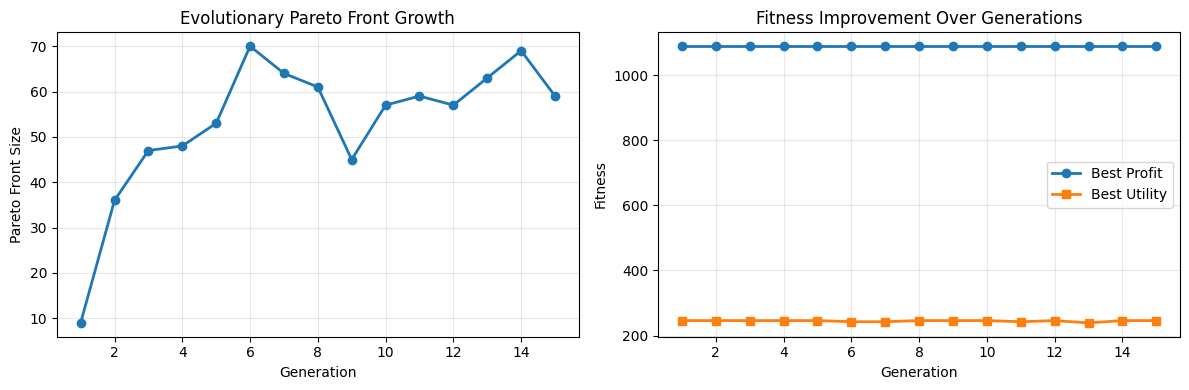


Evolution Summary:
    generation  pop_size  pareto_size  best_profit  best_utility
0            1       150            9       1089.0        246.20
1            2       150           36       1089.0        246.20
2            3       150           47       1089.0        246.20
3            4       150           48       1089.0        246.20
4            5       150           53       1089.0        246.20
5            6       150           70       1089.0        242.65
6            7       150           64       1089.0        242.65
7            8       150           61       1089.0        246.20
8            9       150           45       1089.0        246.20
9           10       150           57       1089.0        246.20
10          11       150           59       1089.0        242.65
11          12       150           57       1089.0        246.20
12          13       150           63       1089.0        239.10
13          14       150           69       1089.0        246.20
14   

In [15]:
# Plot evolution history
hist_df = pd.DataFrame(evo_optimizer.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Pareto size growth
axes[0].plot(hist_df["generation"], hist_df["pareto_size"], marker="o", linewidth=2, markersize=6)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Pareto Front Size")
axes[0].set_title("Evolutionary Pareto Front Growth")
axes[0].grid(True, alpha=0.3)

# Plot 2: Fitness improvement
axes[1].plot(hist_df["generation"], hist_df["best_profit"], marker="o", label="Best Profit", linewidth=2)
axes[1].plot(hist_df["generation"], hist_df["best_utility"], marker="s", label="Best Utility", linewidth=2)
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Fitness")
axes[1].set_title("Fitness Improvement Over Generations")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEvolution Summary:")
print(hist_df.to_string())


## Compare: Random Sampling vs Evolutionary Approach


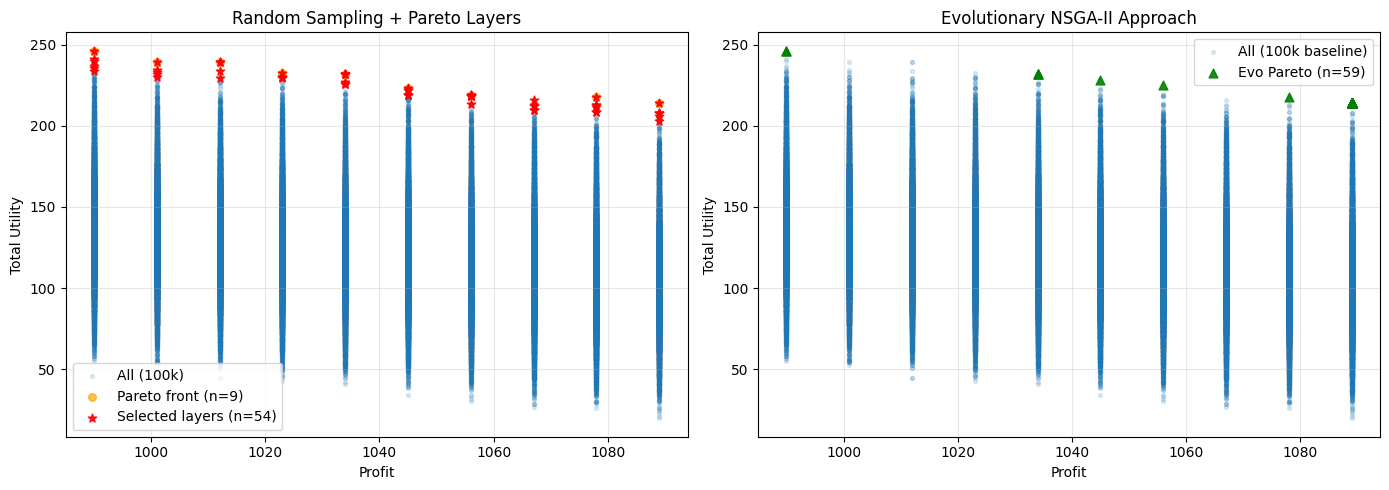


COMPARISON: Random Sampling vs Evolutionary

1. RANDOM SAMPLING (100k policies):
   - Strict Pareto size: 9
   - Selected (layers) size: 54
   - Profit range: [990.00, 1089.00]
   - Utility range: [202.80, 246.20]
   - Pareto ratio: 0.01% of feasible

2. EVOLUTIONARY APPROACH (15 generations):
   - Final Pareto size: 59
   - Profit range: [990.00, 1089.00]
   - Utility range: [214.25, 246.20]
   - Coverage vs all 100k: 0.0597%

3. OPTIONS AVAILABLE:
   - Random: 54 diverse policies with clear trade-offs
   - Evolutionary: 59 optimal policies focused on Pareto frontier

   → Use RANDOM for student exploration (more options)
   → Use EVOLUTIONARY for robust optimization (pure Pareto)



In [16]:
# Create dataframe from evolutionary Pareto front
evo_policies = []
for i, ind in enumerate(evo_pop):
    # Convert numpy types to native Python types for JSON serialization
    row_dict = {k: float(v) for k, v in zip(MULT_KEYS + PEN_KEYS, ind)}
    row_dict["policy_id"] = policy_id_from_dict(row_dict)
    row_dict["profit"] = evo_fitness[i, 0]
    row_dict["total_utility"] = evo_fitness[i, 1]
    evo_policies.append(row_dict)

evo_df = pd.DataFrame(evo_policies)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random sampling result (from earlier)
axes[0].scatter(df_ok["profit"], df_ok["total_utility"], s=8, alpha=0.15, label="All (100k)")
axes[0].scatter(pareto_front_df["profit"], pareto_front_df["total_utility"], 
               s=30, alpha=0.7, color="orange", label=f"Pareto front (n={len(pareto_front_df)})")
axes[0].scatter(selected_df["profit"], selected_df["total_utility"], 
               s=40, alpha=0.9, color="red", marker="*", label=f"Selected layers (n={len(selected_df)})")
axes[0].set_xlabel("Profit")
axes[0].set_ylabel("Total Utility")
axes[0].set_title("Random Sampling + Pareto Layers")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Evolutionary approach result
axes[1].scatter(df_ok["profit"], df_ok["total_utility"], s=8, alpha=0.15, label="All (100k baseline)")
axes[1].scatter(evo_df["profit"], evo_df["total_utility"], 
               s=40, alpha=0.9, color="green", marker="^", label=f"Evo Pareto (n={len(evo_df)})")
axes[1].set_xlabel("Profit")
axes[1].set_ylabel("Total Utility")
axes[1].set_title("Evolutionary NSGA-II Approach")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("\n" + "="*70)
print("COMPARISON: Random Sampling vs Evolutionary")
print("="*70)
print(f"\n1. RANDOM SAMPLING (100k policies):")
print(f"   - Strict Pareto size: {len(pareto_front_df)}")
print(f"   - Selected (layers) size: {len(selected_df)}")
print(f"   - Profit range: [{selected_df['profit'].min():.2f}, {selected_df['profit'].max():.2f}]")
print(f"   - Utility range: [{selected_df['total_utility'].min():.2f}, {selected_df['total_utility'].max():.2f}]")
print(f"   - Pareto ratio: {100*len(pareto_front_df)/len(df_ok):.2f}% of feasible")

print(f"\n2. EVOLUTIONARY APPROACH (15 generations):")
print(f"   - Final Pareto size: {len(evo_df)}")
print(f"   - Profit range: [{evo_df['profit'].min():.2f}, {evo_df['profit'].max():.2f}]")
print(f"   - Utility range: [{evo_df['total_utility'].min():.2f}, {evo_df['total_utility'].max():.2f}]")
print(f"   - Coverage vs all 100k: {100*len(evo_df)/len(df_ok):.4f}%")

print(f"\n3. OPTIONS AVAILABLE:")
print(f"   - Random: {len(selected_df)} diverse policies with clear trade-offs")
print(f"   - Evolutionary: {len(evo_df)} optimal policies focused on Pareto frontier")
print(f"\n   → Use RANDOM for student exploration (more options)")
print(f"   → Use EVOLUTIONARY for robust optimization (pure Pareto)")

print("\n" + "="*70)


## Export Evolutionary Results


In [17]:
# Export evolutionary results to Excel
OUT_XLSX_EVO = Path("policy_pool_evolutionary.xlsx")

# Prepare readable version
evo_readable = make_readable(evo_df[["policy_id"] + MULT_KEYS + PEN_KEYS])

# Export
with pd.ExcelWriter(OUT_XLSX_EVO, engine="openpyxl") as writer:
    # Numeric (clean for app loading)
    evo_df[["policy_id"] + MULT_KEYS + PEN_KEYS].to_excel(
        writer, sheet_name="policies", index=False
    )
    # Readable (human-friendly)
    evo_readable.to_excel(writer, sheet_name="readable", index=False)
    # Full metrics
    evo_df.to_excel(writer, sheet_name="all_metrics", index=False)
    
    # Comparison summary
    comparison_data = {
        "Method": ["Random Sampling", "Evolutionary NSGA-II"],
        "Pareto Size": [len(selected_df), len(evo_df)],
        "Min Profit": [selected_df["profit"].min(), evo_df["profit"].min()],
        "Max Profit": [selected_df["profit"].max(), evo_df["profit"].max()],
        "Min Utility": [selected_df["total_utility"].min(), evo_df["total_utility"].min()],
        "Max Utility": [selected_df["total_utility"].max(), evo_df["total_utility"].max()],
    }
    pd.DataFrame(comparison_data).to_excel(writer, sheet_name="comparison", index=False)

print(f"✓ Evolutionary results exported to: {OUT_XLSX_EVO.resolve()}")
print(f"\n  Sheets:")
print(f"  - 'policies': {len(evo_df)} policies (numeric, ready for app)")
print(f"  - 'readable': human-friendly labels (Low/Mid/High, Yes/No)")
print(f"  - 'all_metrics': profit, utility, and diagnostics")
print(f"  - 'comparison': summary stats vs random sampling")


✓ Evolutionary results exported to: C:\Users\LENOVO\Desktop\Asistan\Arya Phone\policy_pool_evolutionary.xlsx

  Sheets:
  - 'policies': 59 policies (numeric, ready for app)
  - 'readable': human-friendly labels (Low/Mid/High, Yes/No)
  - 'all_metrics': profit, utility, and diagnostics
  - 'comparison': summary stats vs random sampling
